# Film Success Prediction (Capstone Final Project)

# Step 4: Modeling - Staying Power (Classification)

## Modeling - Revenue Prediction (Regression) complete
## Next: A film has strong staying power if it achieves **high engagement** (many votes) *and* **above-average rating**.

### This is a practical proxy for:
- sustained word-of-mouth,
- repeat viewing,
- a larger audience footprint.

## Evaluation metrics

Because classification thresholds matter for business decisions, I will evaluate with:
- **ROC-AUC** (overall ranking quality across thresholds)
- **F1** (balance between precision and recall at a chosen threshold)


In [1]:
# Core
import os
from pathlib import Path
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Sklearn
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "sample_data"
DATA_DIR.mkdir(exist_ok=True)


## 1) Load feature-engineered dataset

In [2]:

df = pd.read_csv(DATA_DIR / "movies_feature_engineered.csv")

# Build label: top-quartile vote_count AND rating above median
vote_q75 = df["vote_count"].quantile(0.75)
rating_median = df["vote_average"].median()

df["staying_power"] = ((df["vote_count"] >= vote_q75) & (df["vote_average"] >= rating_median)).astype(int)

df["staying_power"].value_counts(normalize=True).rename("share")


,share
staying_power,
0,0.811531
1,0.188469


## 2) Feature set (exclude revenue to avoid leakage)

In [ ]:

features = [
    "budget", "runtime", "release_year",
    "primary_genre", "original_language",
    "popularity"
]

X = df[features].copy()
y = df["staying_power"].copy()

cat_cols = ["primary_genre", "original_language"]
num_cols = [c for c in features if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)


## 3) Split data

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_train.mean(), y_test.mean()


(np.float64(0.1883720930232558), np.float64(0.18885448916408668))

## 4) Train multiple models with CV

In [5]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

clf_models = {
    "LogisticRegression": LogisticRegression(max_iter=5000),
    "RandomForest": RandomForestClassifier(random_state=42, n_estimators=400),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "SVC (RBF)": SVC(probability=True, random_state=42)
}

scoring = {"roc_auc": "roc_auc", "f1": "f1"}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for name, model in clf_models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    scores = cross_validate(pipe, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1, error_score="raise")
    rows.append({
        "model": name,
        "ROC-AUC (CV)": scores["test_roc_auc"].mean(),
        "F1 (CV)": scores["test_f1"].mean()
    })

results = pd.DataFrame(rows).sort_values("ROC-AUC (CV)", ascending=False)
results


,model,ROC-AUC (CV),F1 (CV)
2,GradientBoosting,0.941495,0.721326
3,SVC (RBF),0.937904,0.709287
1,RandomForest,0.934516,0.717986
0,LogisticRegression,0.928629,0.657694


## 5) GridSearch hyperparameters for best-performing models

In [6]:

# Tune Logistic Regression + RandomForest (common strong baselines)
logreg_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

rf_grid = {
    "model__n_estimators": [400, 800],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5]
}

def run_gs(model, grid):
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    gs = GridSearchCV(pipe, grid, scoring="roc_auc", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    return gs

gs_logreg = run_gs(LogisticRegression(max_iter=5000), logreg_grid)
gs_rf = run_gs(RandomForestClassifier(random_state=42), rf_grid)

print("Best LogReg ROC-AUC (CV):", gs_logreg.best_score_, "Params:", gs_logreg.best_params_)
print("Best RF ROC-AUC (CV):", gs_rf.best_score_, "Params:", gs_rf.best_params_)


Best LogReg ROC-AUC (CV): 0.9296579855783422 Params: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best RF ROC-AUC (CV): 0.9362156810378526 Params: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}


## 6) Final evaluation on the holdout test set

In [7]:

def eval_classifier(model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "ROC-AUC (test)": roc_auc_score(y_test, proba),
        "F1 (test)": f1_score(y_test, pred),
        "Accuracy (test)": accuracy_score(y_test, pred)
    }, pred, proba

logreg_metrics, logreg_pred, logreg_proba = eval_classifier(gs_logreg.best_estimator_, X_test, y_test)
rf_metrics, rf_pred, rf_proba = eval_classifier(gs_rf.best_estimator_, X_test, y_test)

pd.DataFrame([
    {"model": "LogisticRegression (tuned)", **logreg_metrics},
    {"model": "RandomForest (tuned)", **rf_metrics},
]).sort_values("ROC-AUC (test)", ascending=False)


,model,ROC-AUC (test),F1 (test),Accuracy (test)
1,RandomForest (tuned),0.947081,0.755187,0.908669
0,LogisticRegression (tuned),0.941872,0.610837,0.877709


### Confusion matrix + classification report (best model)

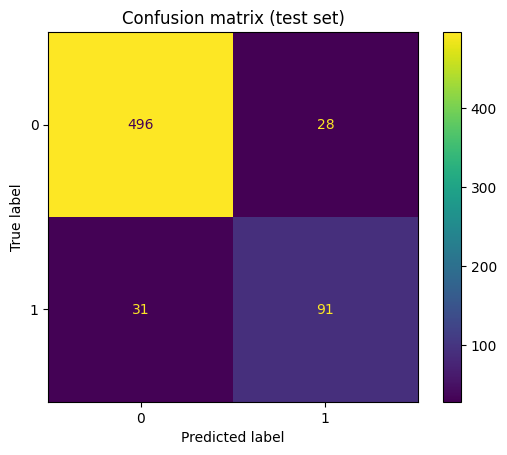

              precision    recall  f1-score   support

           0      0.941     0.947     0.944       524
           1      0.765     0.746     0.755       122

    accuracy                          0.909       646
   macro avg      0.853     0.846     0.850       646
weighted avg      0.908     0.909     0.908       646



In [8]:

best_clf = gs_rf.best_estimator_ if rf_metrics["ROC-AUC (test)"] >= logreg_metrics["ROC-AUC (test)"] else gs_logreg.best_estimator_
best_pred = rf_pred if best_clf is gs_rf.best_estimator_ else logreg_pred
best_proba = rf_proba if best_clf is gs_rf.best_estimator_ else logreg_proba

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion matrix (test set)")
plt.show()

print(classification_report(y_test, best_pred, digits=3))


### ROC curve

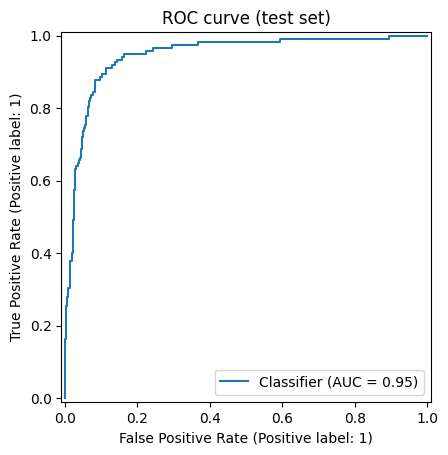

In [9]:

RocCurveDisplay.from_predictions(y_test, best_proba)
plt.title("ROC curve (test set)")
plt.show()


## 7) Interpretation: what features are associated with staying power?

,feature,importance_mean,importance_std
5,popularity,0.338658,0.024989
1,runtime,0.012356,0.004075
3,primary_genre,0.003712,0.003584
2,release_year,0.003240,0.002771
4,original_language,0.000152,0.001249
0,budget,-0.000849,0.003464


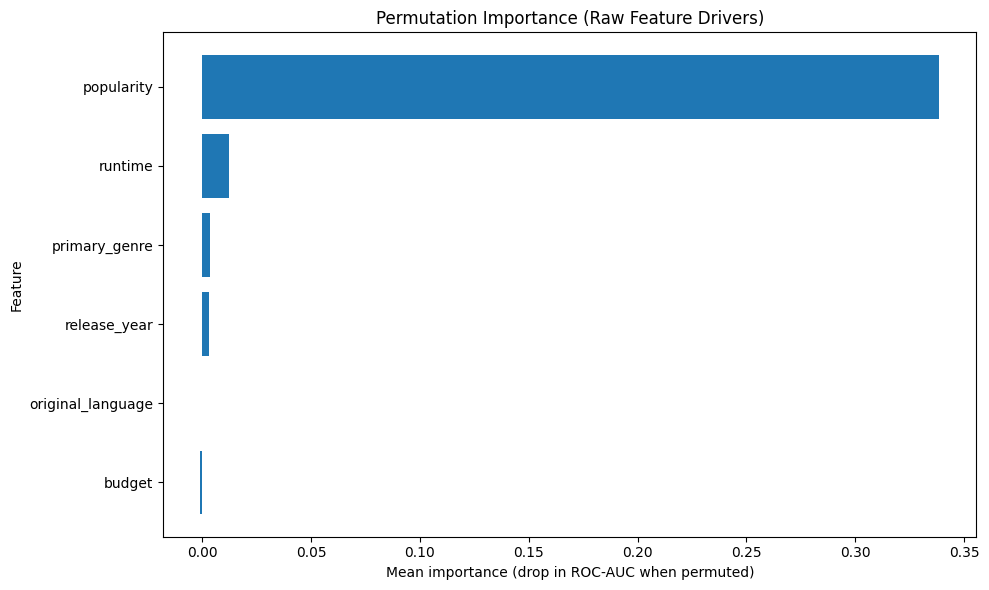

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

final_pipe = best_clf

model = final_pipe.named_steps["model"]

# Tree model: use permutation importance on RAW features
perm = permutation_importance(
    final_pipe,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

if hasattr(X_test, "columns"):
    feature_names = X_test.columns.to_list()
else:
    feature_names = [f"feature_{i}" for i in range(len(perm.importances_mean))]

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df)

# Plot top 15
topn = min(15, len(perm_df))
plt.figure(figsize=(10, 6))
plt.barh(
    perm_df["feature"].head(topn)[::-1],
    perm_df["importance_mean"].head(topn)[::-1]
)
plt.title("Permutation Importance (Raw Feature Drivers)")
plt.xlabel("Mean importance (drop in ROC-AUC when permuted)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Business-facing takeaways (translate model findings)

- Staying power is associated with a combination of **reach** (visibility) and **audience satisfaction**.
- In this proxy definition, **popularity**, runtime and certain genres often correlate with staying power, but these patterns vary.
- This suggests actionable strategies: prioritize marketing/distribution for high-likelihood films, and tailor genre strategy by expected engagement.
